# 02 – Random Forest

Nichtlineares Ensemble-Modell — Test auf H4 (nichtlinear > linear) und H2 (Zeitfeatures).

| Modell       | Features                                                                    |
|--------------|-----------------------------------------------------------------------------|
| **Model A**  | Strahlung + Wetter (4 Features, **ohne** Zeitfeatures)                      |
| **Model B**  | + `hour_cos_shifted`, `month_cos_shifted` (6 Features, **mit** Zeitfeatures)|

**Forschungshypothesen:**
- **H2:** Zeitliche Merkmale verbessern die Prognose signifikant (MAE(mit Zeit) < MAE(ohne))
- **H4:** Nichtlineare Modelle übertreffen lineare Regression (MAE(RF) < MAE(linear))

## 0 · Setup

In [ ]:
import sys
sys.path.insert(0, '../..')

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from src.data.preprocessing import load_processed_data
from src.data.splitting import time_series_split, split_summary
from src.features.feature_sets import FEATURE_SETS
from src.models.naive import fit_climatological_mean_by_season, predict_climatological_mean_by_season
from src.models.pipeline import run_pipeline, evaluate_on_test
from src.evaluation.metrics import evaluate, persistence_forecast

P_NOM       = 13_500.0
TARGET      = 'Solarproduktion'
RESULTS_DIR = Path('../../results/02_random_forest')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RUN_TEST = False  # flip to True once, deliberately, when finalizing results

FEATURES_A = FEATURE_SETS["BASE"].features
FEATURES_B = FEATURE_SETS["BASE_WITH_TIME"].features

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})

## 1 · Daten laden & Split

## 2 · Feature-Übersicht

Features werden aus `data/processed/features.csv` geladen (vorberechnet in `04_feature_engineering.ipynb`).

| Modell       | Features                                                                    |
|--------------|-----------------------------------------------------------------------------|
| **Model A**  | Strahlung + Wetter (4 Features, **ohne** Zeitfeatures)                      |
| **Model B**  | + `hour_cos_shifted`, `month_cos_shifted` (6 Features, **mit** Zeitfeatures)|

In [ ]:
df = load_processed_data()
train, val, test = time_series_split(df)

train = train.dropna(subset=FEATURES_B + [TARGET])
val   = val.dropna(subset=FEATURES_B + [TARGET])
test  = test.dropna(subset=FEATURES_B + [TARGET])

split_summary(train, val, test)

## 4 · Modell trainieren

| Hyperparameter | Wert | Begründung |
|---|---|---|
| `n_estimators` | 300 | Genug Bäume für stabile OOB-Schätzung |
| `max_features` | `'sqrt'` | Standardwert für Regression; reduziert Korrelation zwischen Bäumen |
| `min_samples_leaf` | 4 | Verhindert Overfitting auf 15-min-Rauschen |
| `n_jobs` | -1 | Alle CPU-Kerne |
| `random_state` | 42 | Reproduzierbarkeit |

In [18]:
y_train = train.set_index('timestamp')[TARGET]
y_val   = val.set_index('timestamp')[TARGET]
y_test  = test.set_index('timestamp')[TARGET]

X_train = train.set_index('timestamp')[FEATURES_B]
X_val   = val.set_index('timestamp')[FEATURES_B]
X_test  = test.set_index('timestamp')[FEATURES_B]

RF_PARAMS = dict(n_estimators=300, max_features='sqrt',
                 min_samples_leaf=4, n_jobs=-1, random_state=42)

# Model A: ohne Zeitfeatures
model_a = RandomForestRegressor(**RF_PARAMS)
model_a.fit(X_train[FEATURES_A], y_train)

# Model B: mit Zeitfeatures
model_b = RandomForestRegressor(**RF_PARAMS)
model_b.fit(X_train[FEATURES_B], y_train)

# Lineare Regression als H4-Referenz
model_lin = LinearRegression()
model_lin.fit(X_train[FEATURES_B], y_train)

print(f'Model A (ohne Zeit): {len(FEATURES_A)} Features')
print(f'Model B (mit Zeit) : {len(FEATURES_B)} Features')

Model A (ohne Zeit): 4 Features
Model B (mit Zeit) : 8 Features


## 5 · Evaluation

Als Referenz-Baseline wird die **Day-Ahead-Persistenz** verwendet:

> **Persistenz-Naive:** Prognose für Tag *t* = gemessene Produktion von Tag *t−1*  
> (gleiche Uhrzeit, 96 × 15-min-Schritte zurück)

Skill Score > 0 bedeutet: das Modell schlägt diesen naiven Ansatz.

In [19]:
def rf_predict(model, X):
    return pd.Series(model.predict(X), index=X.index)

pred_a_val  = rf_predict(model_a, X_val[FEATURES_A])
pred_b_val  = rf_predict(model_b, X_val[FEATURES_B])
pred_a_test = rf_predict(model_a, X_test[FEATURES_A])
pred_b_test = rf_predict(model_b, X_test[FEATURES_B])
pred_lin_val  = pd.Series(model_lin.predict(X_val[FEATURES_B]),  index=X_val.index)
pred_lin_test = pd.Series(model_lin.predict(X_test[FEATURES_B]), index=X_test.index)

pers_val  = persistence_forecast(y_val)
pers_test = persistence_forecast(y_test)

# Klimatologische Baseline (Stunden-Mittelwert je Jahreszeit, auf Trainingsset gefittet)
clim_means     = fit_climatological_mean_by_season(train, TARGET)
clim_val_pred  = predict_climatological_mean_by_season(clim_means, val)
clim_val_pred.index  = y_val.index
clim_test_pred = predict_climatological_mean_by_season(clim_means, test)
clim_test_pred.index = y_test.index

rows = {}
for name, yt, yp, yr in [
    ('Klimatologie (val)',         y_val,  clim_val_pred,  pers_val),
    ('Linear – mit Zeit (val)',    y_val,  pred_lin_val,   pers_val),
    ('RF A – ohne Zeit (val)',     y_val,  pred_a_val,     pers_val),
    ('RF B – mit Zeit (val)',      y_val,  pred_b_val,     pers_val),
    ('Klimatologie (test)',        y_test, clim_test_pred, pers_test),
    ('Linear – mit Zeit (test)',   y_test, pred_lin_test,  pers_test),
    ('RF A – ohne Zeit (test)',    y_test, pred_a_test,    pers_test),
    ('RF B – mit Zeit (test)',     y_test, pred_b_test,    pers_test),
]:
    rows[name] = evaluate(yt, yp, P_NOM, y_ref=yr)

results_df = pd.DataFrame(rows).T
results_df[['rmse', 'mae', 'r2', 'nrmse', 'skill_mae']].round(4)

,rmse,mae,r2,nrmse,skill_mae
Klimatologie (val),433.2560,184.4871,0.5561,0.0321,0.1275
Linear – mit Zeit (val),441.4705,237.1563,0.5391,0.0327,-0.1204
RF A – ohne Zeit (val),488.7883,238.8655,0.4350,0.0362,-0.1293
RF B – mit Zeit (val),393.6384,146.8404,0.6336,0.0292,0.3076
Klimatologie (test),461.3455,185.3174,0.4954,0.0342,0.1080
Linear – mit Zeit (test),450.7526,237.2658,0.5183,0.0334,-0.1399
RF A – ohne Zeit (test),475.0555,206.4191,0.4649,0.0352,0.0060
RF B – mit Zeit (test),376.0478,140.2274,0.6647,0.0279,0.3249


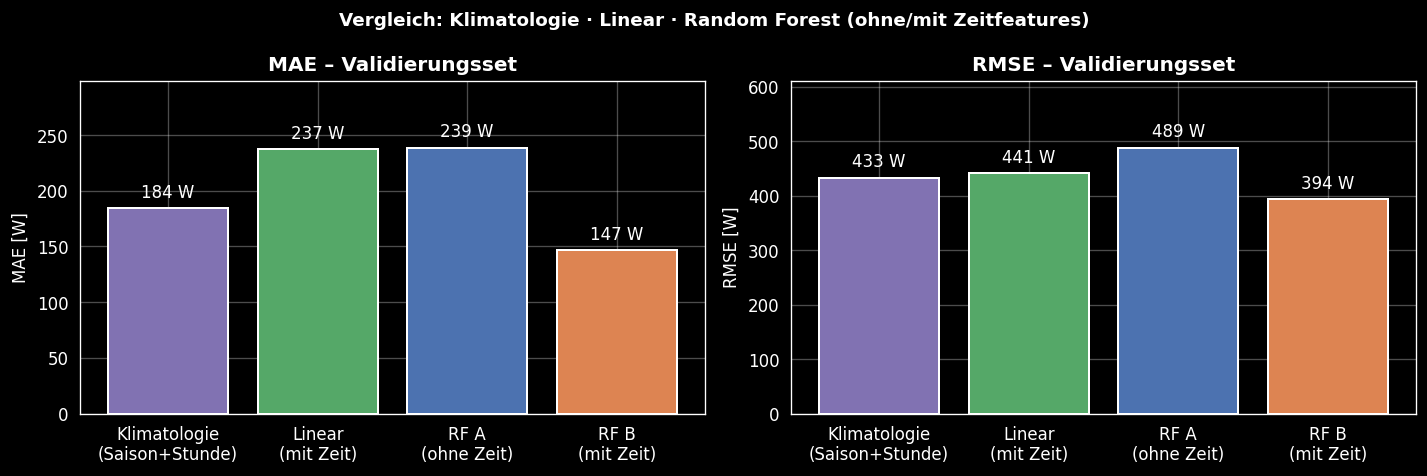

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = [
    'Klimatologie (val)',
    'Linear – mit Zeit (val)', 'RF A – ohne Zeit (val)', 'RF B – mit Zeit (val)',
]
labels = ['Klimatologie\n(Saison+Stunde)', 'Linear\n(mit Zeit)', 'RF A\n(ohne Zeit)', 'RF B\n(mit Zeit)']
colors = ['#8172B2', '#55A868', '#4C72B0', '#DD8452']

for ax, metric, title in [
    (axes[0], 'mae',  'MAE – Validierungsset'),
    (axes[1], 'rmse', 'RMSE – Validierungsset'),
]:
    vals = [results_df.loc[m, metric] for m in models]
    bars = ax.bar(labels, vals, color=colors, edgecolor='white', linewidth=1.2)
    ax.bar_label(bars, fmt='%.0f W', padding=4, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{metric.upper()} [W]')
    ax.set_ylim(0, max(vals) * 1.25)

plt.suptitle('Vergleich: Klimatologie · Linear · Random Forest (ohne/mit Zeitfeatures)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 6 · Beispielwoche

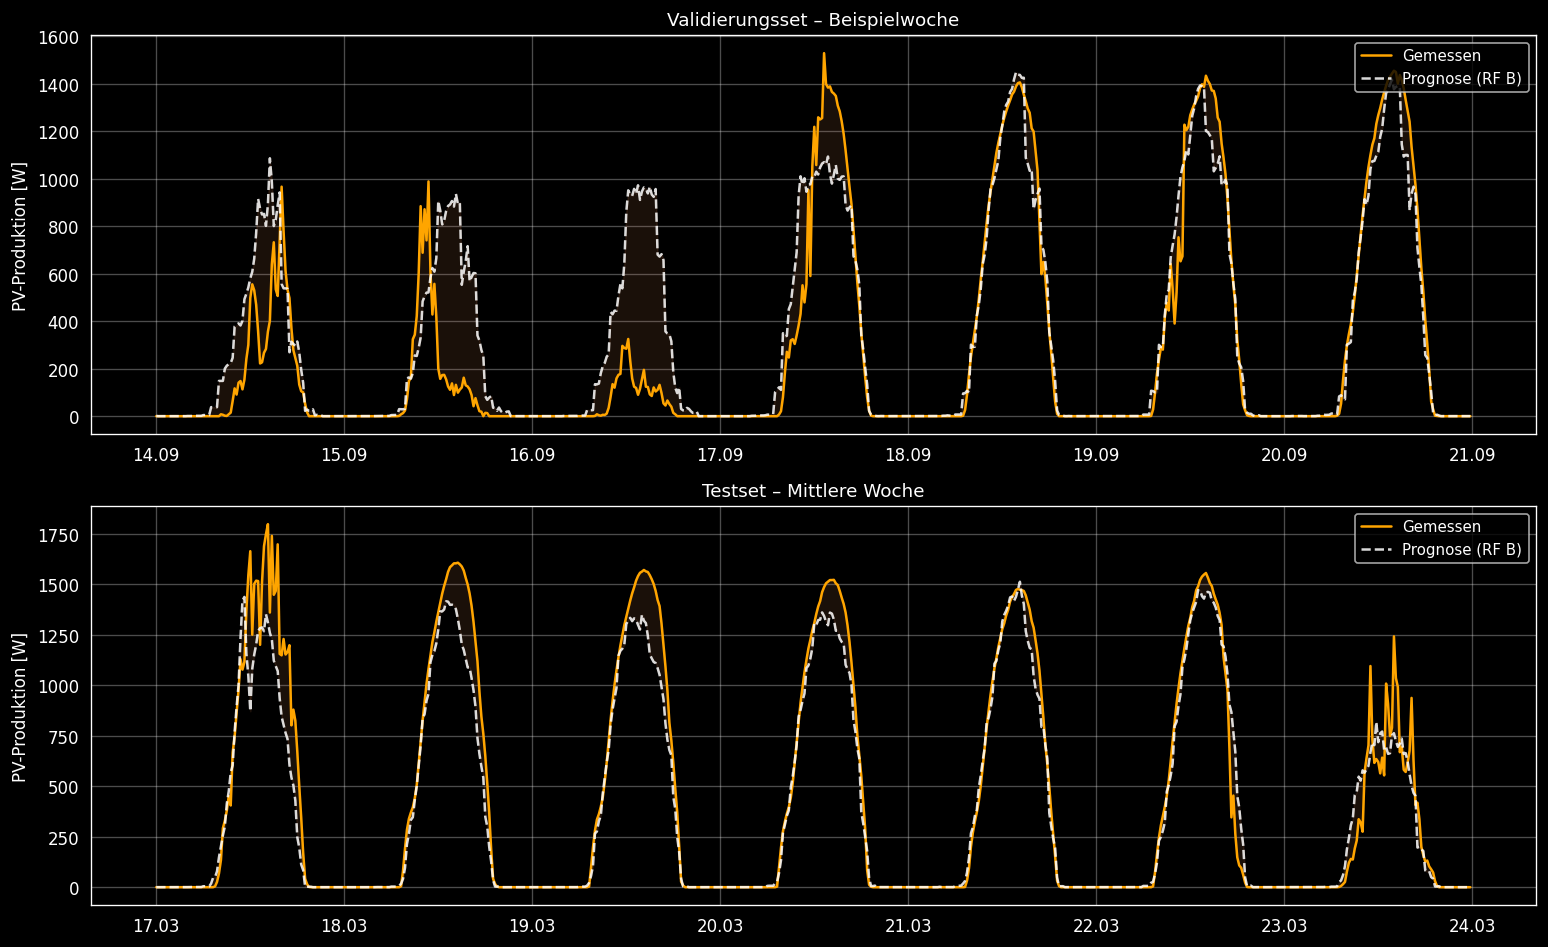

In [27]:
def plot_week(ax, df_split, y_pred, title):
    mid  = df_split['timestamp'].iloc[len(df_split) // 2].floor('D')
    mask = (df_split['timestamp'] >= mid) & (
           df_split['timestamp'] <  mid + pd.Timedelta(days=7))
    sub  = df_split[mask].set_index('timestamp')
    pred = y_pred.reindex(sub.index)
    ax.plot(sub.index, sub[TARGET], label='Gemessen',
            color='orange', linewidth=1.5)
    ax.plot(sub.index, pred, label='Prognose (RF B)',
            color='white', linewidth=1.5, linestyle='--', alpha=0.85)
    ax.fill_between(sub.index, sub[TARGET], pred, alpha=0.12, color='#DD8452')
    ax.set_title(title, fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylabel('PV-Produktion [W]')

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)
plot_week(axes[0], val,  pred_b_val,  'Validierungsset – Beispielwoche')
plot_week(axes[1], test, pred_b_test, 'Testset – Mittlere Woche')
plt.tight_layout()
plt.show()

## 7 · Residualanalyse

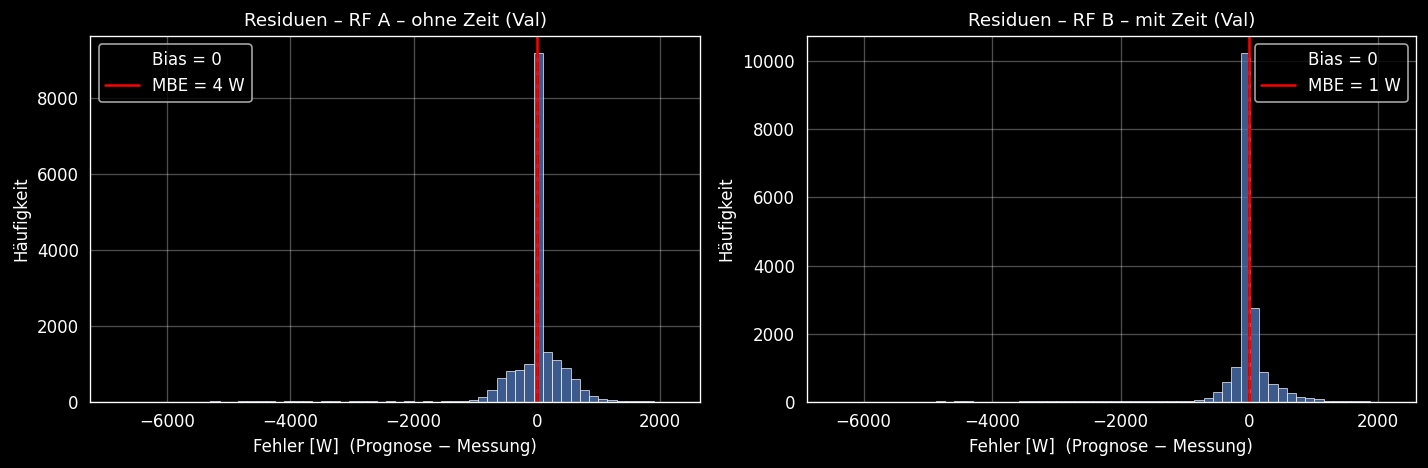

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, yt, yp in [
    (axes[0], 'RF A – ohne Zeit (Val)', y_val, pred_a_val),
    (axes[1], 'RF B – mit Zeit (Val)',  y_val, pred_b_val),
]:
    res = (yp - yt).dropna()
    ax.hist(res, bins=60, color='#4C72B0', edgecolor='white',
            linewidth=0.5, alpha=0.8)
    ax.axvline(0,          color='black', lw=1.5, ls='--', label='Bias = 0')
    ax.axvline(res.mean(), color='red',   lw=1.5, ls='-',
               label=f'MBE = {res.mean():.0f} W')
    ax.set_title(f'Residuen – {name}', fontsize=11)
    ax.set_xlabel('Fehler [W]  (Prognose − Messung)')
    ax.set_ylabel('Häufigkeit')
    ax.legend()

plt.tight_layout()
plt.show()

## 8 · Feature Importance

Mittlere Impurity-Reduktion (MDI) über alle Bäume — zeigt welche Features der Random Forest am stärksten nutzt.

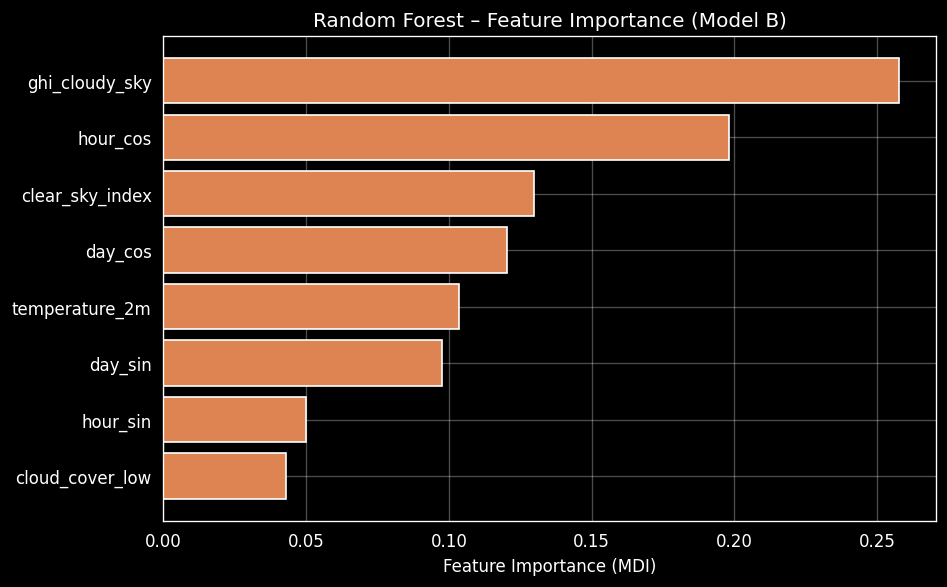

                 importance
feature                    
ghi_cloudy_sky       0.2578
hour_cos             0.1982
clear_sky_index      0.1297
day_cos              0.1205
temperature_2m       0.1034
day_sin              0.0975
hour_sin             0.0498
cloud_cover_low      0.0431


In [23]:
imp_df = pd.DataFrame({
    'feature':    FEATURES_B,
    'importance': model_b.feature_importances_,
}).set_index('feature').sort_values('importance')

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df.index, imp_df['importance'],
        color='#DD8452', edgecolor='white')
ax.set_xlabel('Feature Importance (MDI)')
ax.set_title('Random Forest – Feature Importance (Model B)', fontsize=12)
plt.tight_layout()
plt.show()

print(imp_df.sort_values('importance', ascending=False).round(4))

## 9 · Ergebnisse speichern

In [ ]:
def make_predict_fn(model):
    def predict_fn(df, features):
        X = df.set_index("timestamp")[features]
        return pd.Series(model.predict(X), index=X.index)
    return predict_fn

seasonal_means = fit_climatological_mean_by_season(train, TARGET)
ref_fn = lambda df, _: predict_climatological_mean_by_season(seasonal_means, df).set_axis(
    df.set_index("timestamp").index
)

for model_name, model, fset in [
    ('random_forest_base',           model_a, 'BASE'),
    ('random_forest_base_with_time', model_b, 'BASE_WITH_TIME'),
]:
    feats = FEATURE_SETS[fset].features
    result = run_pipeline(
        model_name=model_name,
        predict_fn=make_predict_fn(model),
        train=train,
        val=val,
        features=feats,
        feature_set_key=fset,
        params=RF_PARAMS,
        results_dir=RESULTS_DIR,
        ref_predict_fn=ref_fn,
    )
    if RUN_TEST:
        evaluate_on_test(result, make_predict_fn(model), test, feats, RESULTS_DIR, ref_predict_fn=ref_fn)
